### V-plot (1 mark)

Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Read data from mapped.bed

In [2]:
file_path = './mapped.bed'  
cols = [str(i) for i in range(1, 14)] 
df = pd.read_csv(file_path, sep='\t', header=None, names=cols)

Transfrom data

In [3]:
C1 = (df['3'] + df['4']) / 2
C2 = (df['9'] + df['10']) / 2

df['X'] = C2 - C1

df['Y'] = df['10'] - df['9']

counts = df.groupby(['X', 'Y']).size().reset_index(name='Z')

heatmap = counts.pivot(index='Y', columns='X', values='Z').fillna(0)

heatmap = heatmap.sort_index(axis=0).sort_index(axis=1)

Plotting

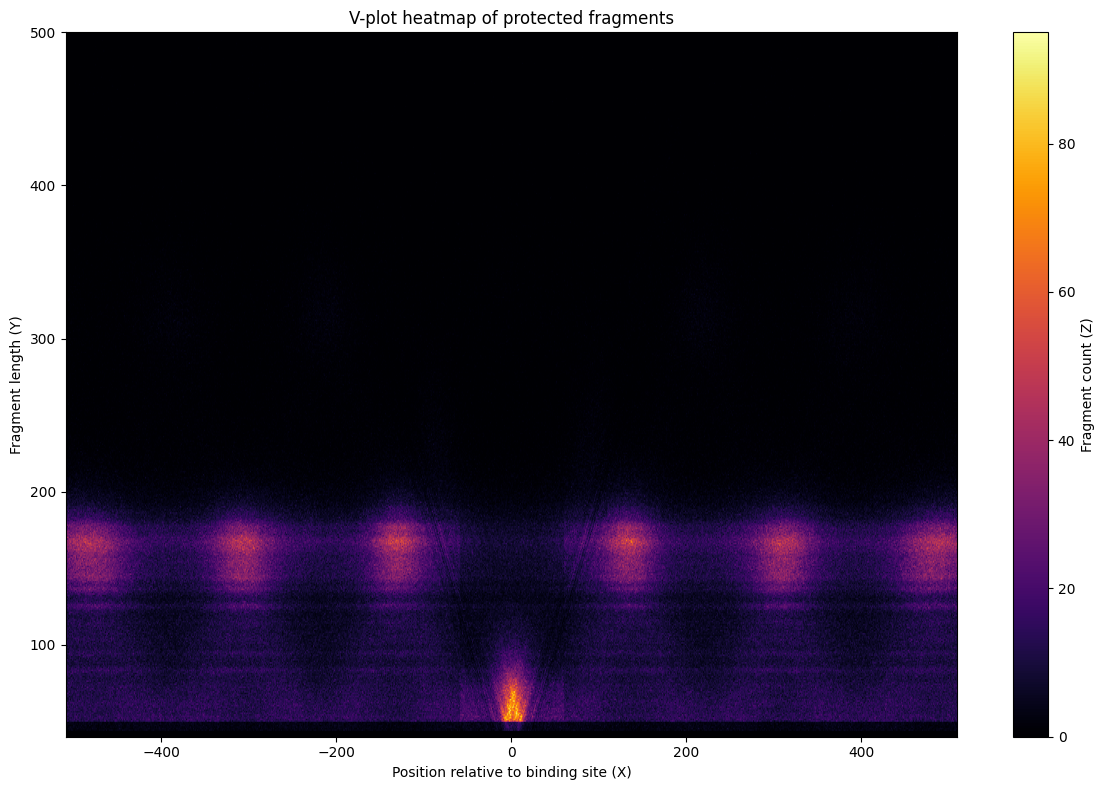

In [4]:
plt.figure(figsize=(12, 8))

plt.imshow(heatmap, aspect='auto', origin='lower', 
           extent=(heatmap.columns.min(), heatmap.columns.max(), heatmap.index.min(), heatmap.index.max()), 
           cmap='inferno', vmin=0, vmax=heatmap.values.max() * 0.5)

plt.colorbar(label='Fragment count (Z)')
plt.xlabel('Position relative to binding site (X)')
plt.ylabel('Fragment length (Y)')
plt.title('V-plot heatmap of protected fragments')
plt.tight_layout()
plt.show()